# Análisis y Detección de Anomalías en Flujos Migratorios Intercondales — EE.UU. (2011–2022)

**Asignatura:** Geo-Data Science / Big Data Geoespacial  
**Autor:** Miguel Alessandro López Tamagno  


## 0. Contexto y preguntas de investigación

El IRS publica cada año cuántos contribuyentes cambiaron de condado de residencia fiscal y cuánta renta ajustada (AGI) llevaron consigo. El dataset cubre once periodos, de 2011-2012 a 2021-2022, con una fila por par origen-destino que incluye el número de declaraciones, individuos y AGI transferido.

El análisis responde ocho preguntas:

1. ¿Qué condados acumulan saldo neto positivo o negativo de AGI en el periodo 2011–2022, y cómo se distribuye ese saldo geográficamente?
2. ¿El saldo AGI presenta autocorrelación espacial significativa, y esa autocorrelación se mantiene estable a lo largo del tiempo?
3. ¿Dónde se forman clústeres locales de saldo alto-alto y bajo-bajo, y coinciden con los clústeres de saldo de individuos?
4. ¿Qué condados rompen su propio comportamiento histórico en años concretos, y qué diferencia hay entre anomalía estadística y anomalía económica?
5. ¿Las anomalías temporales de 2020 se agrupan geográficamente, y a qué escala métrica opera esa dependencia espacial?
6. ¿Qué condados son hubs estructurales de la red de flujos de AGI, independientemente de su saldo neto?
7. ¿La distribución de saldos de 2020 es estadísticamente distinta a la de años anteriores?
8. ¿Harvey (2017) y el COVID-19 (2020) dejan huella detectable en los saldos de renta intercondales?

## 1. Carga de datos y construcción de saldos

In [28]:
# Elaboración propia
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import os
import warnings

from scipy import stats
from scipy.stats import zscore, ks_2samp

from libpysal.weights import Queen, KNN
from esda import Moran, Moran_Local, Moran_BV, Moran_Local_BV

import statsmodels.api as sm
import statsmodels.formula.api as smf

import networkx as nx
import skgstat as skg
import mapclassify

from numba.core.errors import NumbaDeprecationWarning, NumbaPendingDeprecationWarning
warnings.simplefilter('ignore', category=NumbaDeprecationWarning)
warnings.simplefilter('ignore', category=FutureWarning)


In [29]:
# Elaboración propia
BASE    = '.'
PARQUET = os.path.join(BASE, 'capa_flujo/capa_flujo.parquet')
SHP     = os.path.join(BASE, 'tl_2022_us_county/tl_2022_us_county.shp')

MAPEO_PERIODOS = {
    '2011-2012': 2011, '2012-2013': 2012, '2013-2014': 2013,
    '2014-2015': 2014, '2015-2016': 2015, '2016-2017': 2016,
    '2017-2018': 2017, '2018-2019': 2018, '2019-2020': 2019,
    '2020-2021': 2020, '2021-2022': 2021
}

flujos = gpd.read_parquet(PARQUET)
flujos['año'] = flujos['Fecha'].map(MAPEO_PERIODOS)
flujos['FIP Origen']  = flujos['FIP Origen'].astype(str).str.zfill(5)
flujos['FIP Destino'] = flujos['FIP Destino'].astype(str).str.zfill(5)

if flujos.crs is None or flujos.crs.to_epsg() != 5070:
    flujos = flujos.to_crs(epsg=5070)
flujos['distancia_km'] = flujos.geometry.length / 1000

gdf = gpd.read_file(SHP)
gdf['FIP'] = gdf['GEOID'].astype(str).str.zfill(5)

# Excluye por construcción los condados que no presentan contigüidad
estados_cont = [str(i).zfill(2) for i in range(1, 57) if i not in [2, 15]]
gdf = gdf[gdf['STATEFP'].isin(estados_cont)].copy()
gdf = gdf.to_crs('ESRI:102003')

print(f'{len(flujos):,} filas de flujos, CRS {flujos.crs.to_epsg()}')
print(f'{len(gdf):,} condados (48 estados + DC), años {sorted(flujos["año"].dropna().unique().astype(int))}')

296,749 filas de flujos, CRS 5070
3,109 condados (48 estados + DC), años [np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021)]


In [30]:
# Elaboración propia
out_anual = flujos.groupby(['año', 'FIP Origen']).agg(
    AGI_out = ('AGI',      'sum'),
    ind_out = ('Saldo',    'sum'),
    ret_out = ('Retornos', 'sum')
).reset_index().rename(columns={'FIP Origen': 'FIP'})

in_anual = flujos.groupby(['año', 'FIP Destino']).agg(
    AGI_in  = ('AGI',      'sum'),
    ind_in  = ('Saldo',    'sum'),
    ret_in  = ('Retornos', 'sum')
).reset_index().rename(columns={'FIP Destino': 'FIP'})

saldos_anual = out_anual.merge(in_anual, on=['FIP', 'año'], how='outer').fillna(0)
saldos_anual['saldo_AGI'] = saldos_anual['AGI_in']  - saldos_anual['AGI_out']
saldos_anual['saldo_ind'] = saldos_anual['ind_in']  - saldos_anual['ind_out']
saldos_anual['saldo_ret'] = saldos_anual['ret_in']  - saldos_anual['ret_out']
saldos_anual['FIP']       = saldos_anual['FIP'].astype(str).str.zfill(5)

saldos_tot = saldos_anual.groupby('FIP')[
    ['saldo_AGI', 'saldo_ind', 'saldo_ret']
].sum().reset_index()

print(f'{len(saldos_tot):,} condados con saldo calculado')
saldos_tot[['saldo_AGI', 'saldo_ind']].describe().round(1)

3,084 condados con saldo calculado


,saldo_AGI,saldo_ind
count,3084.0,3084.0
mean,0.0,0.0
std,1767267.5,29563.9
min,-25541841.0,-300482.0
25%,-37639.0,-1084.8
50%,-237.5,-18.0
75%,10922.2,418.0
max,47575026.0,879343.0


La media del saldo AGI es cero por construcción: el dinero que sale de un condado entra en otro. La dispersión es lo que importa. Desviación típica de 1,77 M$, rango de −25,5 a +47,6 M$, mediana en −237 miles. El 50% central queda entre −38k y +11k. La información está en los extremos; el 50% central es ruido de fondo.

## 2. EDA temporal

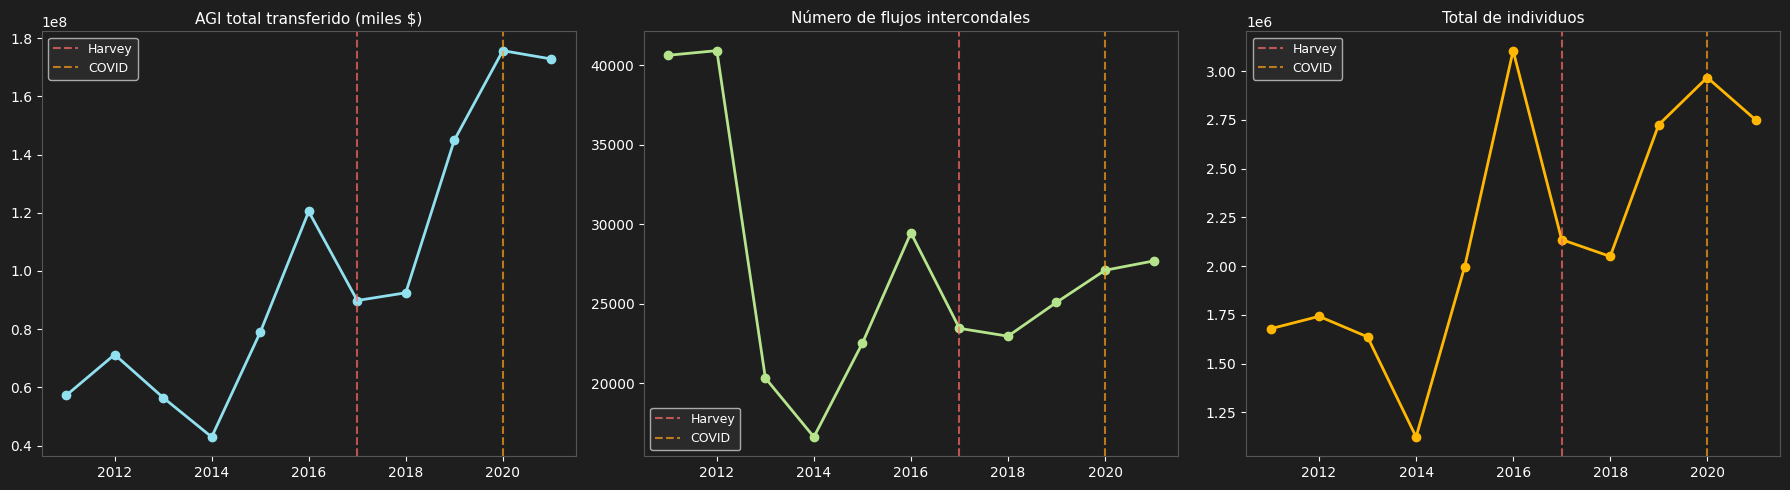

In [31]:
# Generado con IA (visualización)
eda_anual = flujos.groupby('año').agg(
    AGI_total   = ('AGI',   'sum'),
    n_flujos    = ('AGI',   'count'),
    saldo_total = ('Saldo', 'sum')
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#1e1e1e')

series = [
    ('AGI_total',   'AGI total transferido (miles $)', '#90e0ef'),
    ('n_flujos',    'Número de flujos intercondales',  '#b5e48c'),
    ('saldo_total', 'Total de individuos',             '#ffb703'),
]

for ax, (col, titulo, color) in zip(axes, series):
    ax.set_facecolor('#1e1e1e')
    ax.plot(eda_anual['año'], eda_anual[col], marker='o', color=color, linewidth=2)
    ax.set_title(titulo, color='white', fontsize=11)
    ax.tick_params(colors='white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#555')
    ax.axvline(2017, color='#ff6b6b', linestyle='--', alpha=0.7, label='Harvey')
    ax.axvline(2020, color='#ff9f1c', linestyle='--', alpha=0.7, label='COVID')
    ax.legend(facecolor='#2e2e2e', labelcolor='white', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(BASE, 'figuras/sec2_eda_temporal.png'),
            dpi=150, bbox_inches='tight', facecolor='#1e1e1e')
plt.show()

El AGI total sube de 57.000 M$ en 2011 a 178.000 M$ en 2020, casi triplicándose en diez años. Solo hay una interrupción clara: el hundimiento de 2013–2014, donde el número de pares activos cae de más de 40.000 a 16.621. Ese suelo de 2014 se replica en los tres paneles, y no corresponde a ningún evento externo conocido — probablemente refleja un cambio de umbral en la publicación del IRS.

A partir de 2015 la recuperación es parcial. El pico de individuos es 2016 (3,1 millones); en 2017 cae un 31%, lo que coincide con Harvey. En 2020 el AGI bate su máximo histórico mientras el número de pares se mantiene en torno a 20.000: menos rutas, pero con más renta media por movimiento.

## 3. Análisis geoespacial estático

Antes de buscar anomalías hay que saber si el saldo AGI tiene estructura espacial. Calculamos el índice de Moran global para cuantificarla, LISA para localizarla por condado, y Moran bivariado para ver si AGI e individuos se agrupan igual en el espacio.

### 3a. Mapa coroplético — saldo neto AGI acumulado (2011–2022)

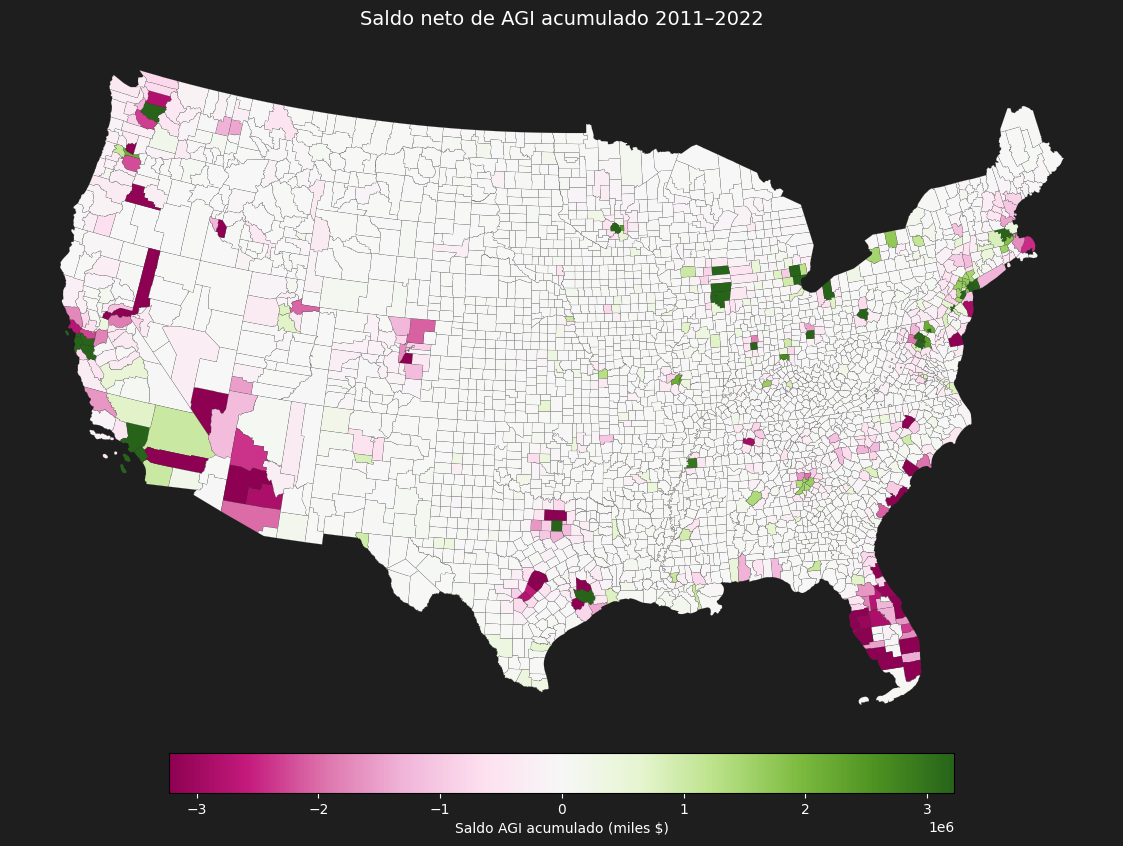

In [32]:
# Generado con IA (visualización)
gdf_tot = gdf.merge(saldos_tot, on='FIP', how='left')
gdf_tot[['saldo_AGI', 'saldo_ind', 'saldo_ret']] = gdf_tot[
    ['saldo_AGI', 'saldo_ind', 'saldo_ret']
].fillna(0)

vmax = np.percentile(np.abs(gdf_tot['saldo_AGI']), 98)

fig, ax = plt.subplots(figsize=(16, 9))
fig.patch.set_facecolor('#1e1e1e')
ax.set_facecolor('#1e1e1e')

gdf_tot.plot(
    column='saldo_AGI',
    ax=ax,
    cmap='PiYG',
    vmin=-vmax,
    vmax=vmax,
    linewidth=0.1,
    edgecolor='#444',
    legend=True,
    legend_kwds={
        'label': 'Saldo AGI acumulado (miles $)',
        'orientation': 'horizontal',
        'shrink': 0.5,
        'pad': 0.02
    }
)

ax.set_title('Saldo neto de AGI acumulado 2011–2022', color='white', fontsize=14, pad=10)
ax.set_axis_off()

# Colorbar en blanco
cbar = ax.get_figure().axes[-1]
cbar.tick_params(colors='white')
cbar.set_xlabel('Saldo AGI acumulado (miles $)', color='white')

plt.tight_layout()
os.makedirs(os.path.join(BASE, 'figuras'), exist_ok=True)
plt.savefig(os.path.join(BASE, 'figuras/sec3a_mapa_saldo_agi.png'),
            dpi=150, bbox_inches='tight', facecolor='#1e1e1e')
plt.show()

*Responde a la pregunta 1.*

La paleta PiYG codifica pérdidas en fucsia y ganancias en verde. El interior continental es casi todo blanco: los saldos próximos a cero dominan y confirman que la concentración es puntual, no difusa. Las pérdidas más intensas están en la costa del Pacífico, con el corredor costero californiano como zona de mayor salida neta. Las ganancias se concentran en el sur de Florida y hay nodos dispersos en el Noreste. El mapa muestra magnitudes; si la distribución es aleatoria o no es lo que calcula el Moran de la sección siguiente.

### 3b. Moran Global univariante — saldo AGI

In [33]:
# Elaboración propia
# Matriz de vecindad Queen
gdf_tot_reset = gdf_tot.reset_index(drop=True)

w_queen = Queen.from_dataframe(gdf_tot_reset, silence_warnings=True)
w_queen.transform = 'r'

print(f'{w_queen.n} condados en la matriz de vecindad, {w_queen.mean_neighbors:.2f} vecinos en promedio')

3109 condados en la matriz de vecindad, 5.94 vecinos en promedio


Moran I = 0.1938  (E[I] = -0.0003, p = 0.0001, 9999 perm.)


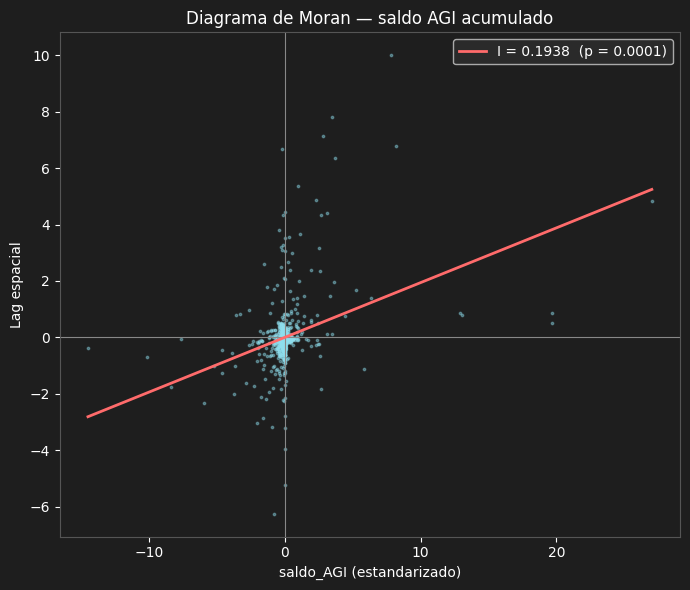

In [34]:
# Generado con IA (visualización)
y_agi = gdf_tot_reset['saldo_AGI'].values

moran_agi = Moran(y_agi, w_queen, permutations=9999)

print(f'Moran I = {moran_agi.I:.4f}  (E[I] = {moran_agi.EI:.4f}, p = {moran_agi.p_sim:.4f}, 9999 perm.)')

# Diagrama de dispersión de Moran
fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor('#1e1e1e')
ax.set_facecolor('#1e1e1e')

y_std  = (y_agi - y_agi.mean()) / y_agi.std()
wy_std = w_queen.sparse.dot(y_std)

ax.scatter(y_std, wy_std, s=3, alpha=0.4, color='#90e0ef')
ax.axhline(0, color='#888', linewidth=0.8)
ax.axvline(0, color='#888', linewidth=0.8)

# Línea de regresión
m, b = np.polyfit(y_std, wy_std, 1)
x_line = np.linspace(y_std.min(), y_std.max(), 200)
ax.plot(x_line, m * x_line + b, color='#ff6b6b', linewidth=2,
        label=f'I = {moran_agi.I:.4f}  (p = {moran_agi.p_sim:.4f})')

ax.set_xlabel('saldo_AGI (estandarizado)', color='white')
ax.set_ylabel('Lag espacial', color='white')
ax.set_title('Diagrama de Moran — saldo AGI acumulado', color='white', fontsize=12)
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('#555')
ax.legend(facecolor='#2e2e2e', labelcolor='white')

plt.tight_layout()
plt.savefig(os.path.join(BASE, 'figuras/sec3b_moran_scatter.png'),
            dpi=150, bbox_inches='tight', facecolor='#1e1e1e')
plt.show()

*Responde a la pregunta 2 (primera parte).*

I = 0,1938, p = 0,0001 con 9.999 permutaciones. La distribución de saldos no es aleatoria en el espacio.

En el diagrama, la nube se aplasta sobre el origen (0, 0): la mayoría de los 3.109 condados tiene z ≈ 0 y lag espacial ≈ 0. La pendiente positiva la generan los outliers de la derecha —condados con z > 15—, que corresponden a los hubs de Florida y del Noreste del coroplético. Con señal tan asimétrica y 3.109 nodos, I = 0,19 descarta ruido espacial, aunque no identifica qué condados concretos lo generan.

### 3c. LISA — clústeres locales de saldo AGI (p < 0.05)

In [35]:
# Elaboración propia
lisa_agi = Moran_Local(y_agi, w_queen, permutations=9999, seed=42)

# Cuadrantes: 1=HH, 2=LH, 3=LL, 4=HL
COLORES_LISA = {
    'HH': '#1b7837',
    'LL': '#762a83',
    'HL': '#a6dba0',
    'LH': '#c2a5cf',
    'NS': '#2e2e2e'
}

gdf_tot_reset['lisa_q']   = lisa_agi.q
gdf_tot_reset['lisa_p']   = lisa_agi.p_sim
gdf_tot_reset['lisa_sig'] = lisa_agi.p_sim < 0.05

def asignar_cluster(row):
    if not row['lisa_sig']:
        return 'NS'
    mapa = {1: 'HH', 2: 'LH', 3: 'LL', 4: 'HL'}
    return mapa.get(row['lisa_q'], 'NS')

gdf_tot_reset['cluster'] = gdf_tot_reset.apply(asignar_cluster, axis=1)

conteos = gdf_tot_reset['cluster'].value_counts()
print(conteos.to_string())

cluster
NS    2840
LL     144
HH      59
LH      45
HL      21


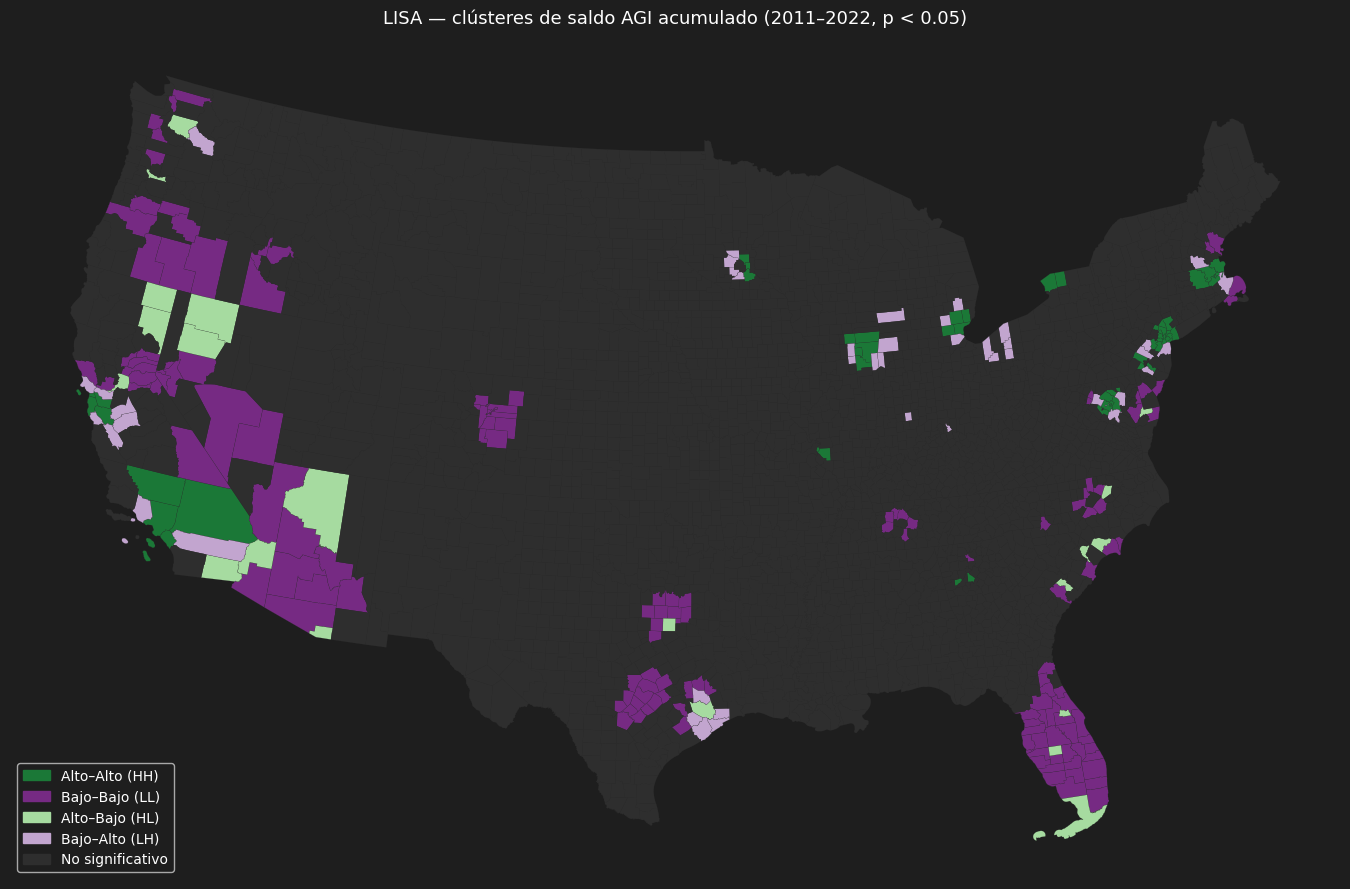

In [36]:
# Generado con IA (visualización)
fig, ax = plt.subplots(figsize=(16, 9))
fig.patch.set_facecolor('#1e1e1e')
ax.set_facecolor('#1e1e1e')

for cluster_tipo, color in COLORES_LISA.items():
    mascara = gdf_tot_reset['cluster'] == cluster_tipo
    gdf_tot_reset[mascara].plot(
        ax=ax, color=color, linewidth=0.1, edgecolor='#333'
    )

# Leyenda manual
etiquetas = {
    'HH': 'Alto–Alto (HH)',
    'LL': 'Bajo–Bajo (LL)',
    'HL': 'Alto–Bajo (HL)',
    'LH': 'Bajo–Alto (LH)',
    'NS': 'No significativo'
}
parches = [
    mpatches.Patch(color=COLORES_LISA[k], label=etiquetas[k])
    for k in ['HH', 'LL', 'HL', 'LH', 'NS']
]
ax.legend(
    handles=parches,
    loc='lower left',
    facecolor='#1e1e1e',
    labelcolor='white',
    fontsize=10,
    framealpha=0.8
)

ax.set_title('LISA — clústeres de saldo AGI acumulado (2011–2022, p < 0.05)',
             color='white', fontsize=13, pad=10)
ax.set_axis_off()

plt.tight_layout()
plt.savefig(os.path.join(BASE, 'figuras/sec3c_lisa_agi.png'),
            dpi=150, bbox_inches='tight', facecolor='#1e1e1e')
plt.show()

*Responde a la pregunta 3 (primera parte).*

269 de 3.109 condados son significativos al 5%, el 8,7%. Los LL (144) son el grupo más numeroso y se concentran en el corredor costero californiano. Los HH (59) están sobre todo en el sur de Florida. Con 144 LL frente a 59 HH, los territorios perdedores están geográficamente más compactos que los ganadores: Florida absorbe renta pero los condados ganadores están dispersos, mientras que la mancha de pérdida californiana es continua. Los LH (45) y HL (21) aparecen en zonas de transición con dinámica distinta a su entorno inmediato.

### 3d. Moran Bivariado — saldo AGI vs. saldo de individuos

In [37]:
# Elaboración propia
y_ind = gdf_tot_reset['saldo_ind'].values

moran_bv = Moran_BV(y_agi, y_ind, w_queen, permutations=9999)

print(f'Moran BV I = {moran_bv.I:.4f}  (p = {moran_bv.p_sim:.4f}, 9999 perm.)')

Moran BV I = 0.1821  (p = 0.0001, 9999 perm.)


In [38]:
# Elaboración propia
lisa_bv = Moran_Local_BV(y_agi, y_ind, w_queen, permutations=9999, seed=42)

gdf_tot_reset['lisa_bv_q']   = lisa_bv.q
gdf_tot_reset['lisa_bv_p']   = lisa_bv.p_sim
gdf_tot_reset['lisa_bv_sig'] = lisa_bv.p_sim < 0.05

def asignar_cluster_bv(row):
    if not row['lisa_bv_sig']:
        return 'NS'
    mapa = {1: 'HH', 2: 'LH', 3: 'LL', 4: 'HL'}
    return mapa.get(row['lisa_bv_q'], 'NS')

gdf_tot_reset['cluster_bv'] = gdf_tot_reset.apply(asignar_cluster_bv, axis=1)

conteos_bv = gdf_tot_reset['cluster_bv'].value_counts()
print(conteos_bv.to_string())

cluster_bv
NS    2852
LL     138
HH      55
LH      42
HL      22


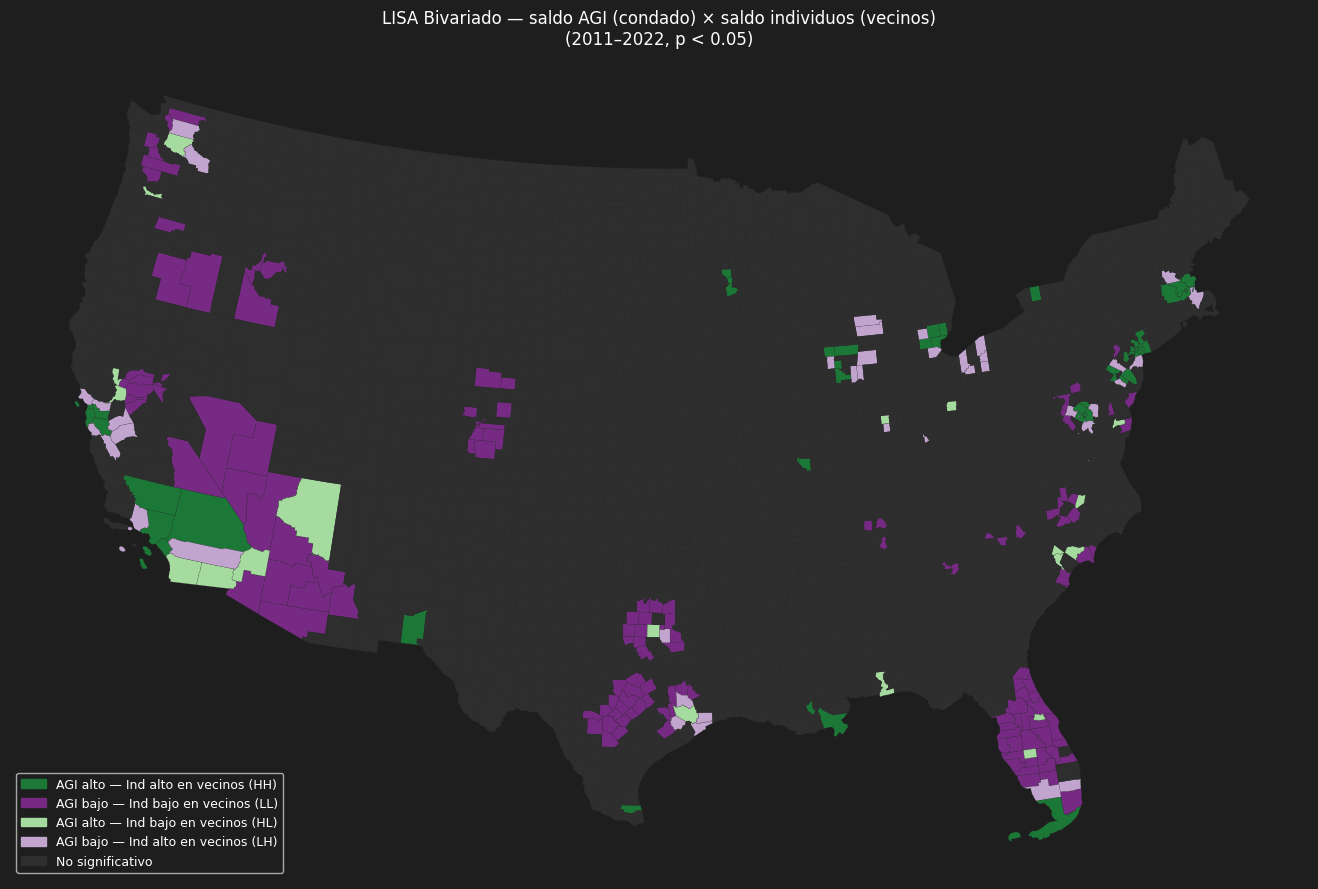

In [39]:
# Generado con IA (visualización)
fig, ax = plt.subplots(figsize=(16, 9))
fig.patch.set_facecolor('#1e1e1e')
ax.set_facecolor('#1e1e1e')

for cluster_tipo, color in COLORES_LISA.items():
    mascara = gdf_tot_reset['cluster_bv'] == cluster_tipo
    gdf_tot_reset[mascara].plot(
        ax=ax, color=color, linewidth=0.1, edgecolor='#333'
    )

etiquetas_bv = {
    'HH': 'AGI alto — Ind alto en vecinos (HH)',
    'LL': 'AGI bajo — Ind bajo en vecinos (LL)',
    'HL': 'AGI alto — Ind bajo en vecinos (HL)',
    'LH': 'AGI bajo — Ind alto en vecinos (LH)',
    'NS': 'No significativo'
}
parches_bv = [
    mpatches.Patch(color=COLORES_LISA[k], label=etiquetas_bv[k])
    for k in ['HH', 'LL', 'HL', 'LH', 'NS']
]
ax.legend(
    handles=parches_bv,
    loc='lower left',
    facecolor='#1e1e1e',
    labelcolor='white',
    fontsize=9,
    framealpha=0.8
)

ax.set_title('LISA Bivariado — saldo AGI (condado) × saldo individuos (vecinos)\n(2011–2022, p < 0.05)',
             color='white', fontsize=12, pad=10)
ax.set_axis_off()

plt.tight_layout()
plt.savefig(os.path.join(BASE, 'figuras/sec3d_lisa_bv.png'),
            dpi=150, bbox_inches='tight', facecolor='#1e1e1e')
plt.show()

*Responde a la pregunta 3 (segunda parte).*

I_BV = 0,1821, p = 0,0001. Casi idéntico al univariante (0,1938). AGI e individuos se desplazan en el mismo sentido y en las mismas zonas. El mapa bivariado reproduce casi punto a punto el univariante: LL = 138, HH = 55.

Los 22 condados HL son los casos más informativos: el condado atrae AGI pero sus vecinos pierden individuos. Aparecen en bordes de áreas metropolitanas de alta renta donde el flujo positivo de capital no se extiende a los condados contiguos.

### 3e. Serie temporal del índice de Moran (2011–2021)

In [40]:
# Elaboración propia
años   = sorted(saldos_anual['año'].unique().astype(int))
moran_I   = []
moran_p   = []

for año in años:
    saldo_año = saldos_anual[saldos_anual['año'] == año][['FIP', 'saldo_AGI']]
    gdf_año   = gdf[['FIP', 'geometry']].merge(saldo_año, on='FIP', how='left')
    gdf_año['saldo_AGI'] = gdf_año['saldo_AGI'].fillna(0)
    gdf_año   = gdf_año.reset_index(drop=True)

    w_año = Queen.from_dataframe(gdf_año, silence_warnings=True)
    w_año.transform = 'r'

    mi = Moran(gdf_año['saldo_AGI'].values, w_año, permutations=999)
    moran_I.append(mi.I)
    moran_p.append(mi.p_sim)
    print(f'{año}: I = {mi.I:.4f}  p = {mi.p_sim:.4f}')

df_moran = pd.DataFrame({'año': años, 'moran_I': moran_I, 'moran_p': moran_p})

2011: I = 0.1172  p = 0.0010
2012: I = 0.0805  p = 0.0010
2013: I = 0.1828  p = 0.0010
2014: I = 0.1735  p = 0.0010
2015: I = 0.1461  p = 0.0010
2016: I = 0.1679  p = 0.0010
2017: I = 0.1689  p = 0.0010
2018: I = 0.1837  p = 0.0010
2019: I = 0.1624  p = 0.0010
2020: I = 0.1971  p = 0.0010
2021: I = 0.2364  p = 0.0010


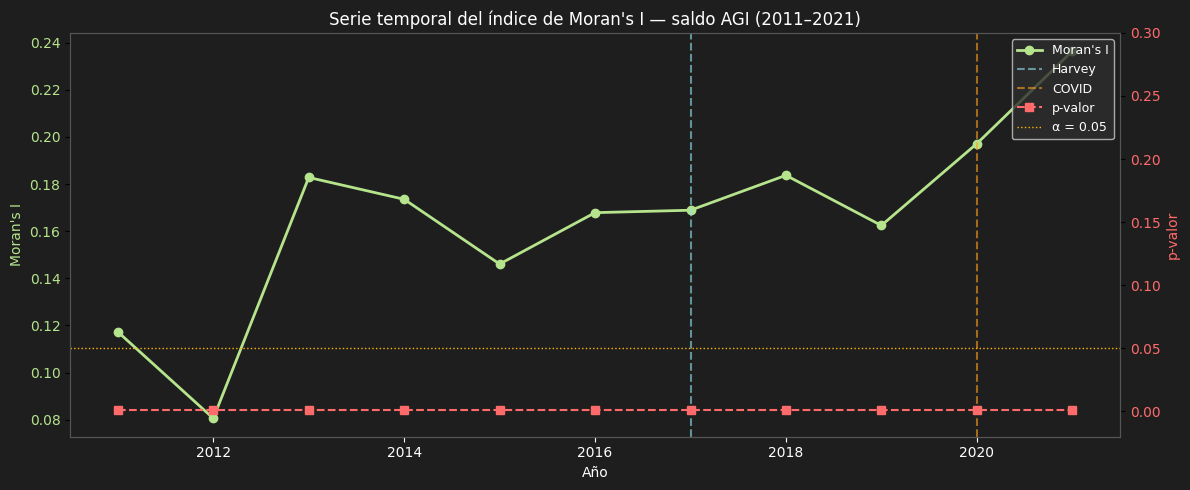

In [41]:
# Generado con IA (visualización)
fig, ax1 = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#1e1e1e')
ax1.set_facecolor('#1e1e1e')

# Eje principal: Moran's I
ax1.plot(df_moran['año'], df_moran['moran_I'],
         marker='o', color='#b5e48c', linewidth=2, label="Moran's I")
ax1.set_xlabel('Año', color='white')
ax1.set_ylabel("Moran's I", color='#b5e48c')
ax1.tick_params(axis='y', labelcolor='#b5e48c')
ax1.tick_params(axis='x', colors='white')
for spine in ax1.spines.values():
    spine.set_edgecolor('#555')

# Eje secundario: p-valor
ax2 = ax1.twinx()
ax2.set_facecolor('#1e1e1e')
ax2.plot(df_moran['año'], df_moran['moran_p'],
         marker='s', color='#ff6b6b', linestyle='--', linewidth=1.5, label='p-valor')
ax2.axhline(0.05, color='#ffb703', linewidth=1, linestyle=':', label='α = 0.05')
ax2.set_ylabel('p-valor', color='#ff6b6b')
ax2.tick_params(axis='y', labelcolor='#ff6b6b')
ax2.set_ylim(-0.02, 0.3)
for spine in ax2.spines.values():
    spine.set_edgecolor('#555')

# Eventos
ax1.axvline(2017, color='#90e0ef', linestyle='--', alpha=0.6, label='Harvey')
ax1.axvline(2020, color='#ff9f1c', linestyle='--', alpha=0.6, label='COVID')

ax1.set_title("Serie temporal del índice de Moran's I — saldo AGI (2011–2021)",
              color='white', fontsize=12)

# Leyenda combinada
lineas1, etiq1 = ax1.get_legend_handles_labels()
lineas2, etiq2 = ax2.get_legend_handles_labels()
ax1.legend(lineas1 + lineas2, etiq1 + etiq2,
           facecolor='#2e2e2e', labelcolor='white', fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig(os.path.join(BASE, 'figuras/sec3e_moran_temporal.png'),
            dpi=150, bbox_inches='tight', facecolor='#1e1e1e')
plt.show()

*Responde a la pregunta 2 (segunda parte).*

El índice de Moran es positivo y significativo en todos los años (p ≤ 0,001 siempre). El mínimo es 2012 (I = 0,08), cuando hay más de 40.000 pares activos y la señal espacial se diluye en el volumen. En 2013, con la mitad de pares, I sube a 0,18: menos flujos pero geográficamente más concentrados.

Harvey 2017 no mueve el índice: 0,169 en 2016, 0,169 en 2017. El huracán fue demasiado local para alterar un estadístico calculado sobre 3.000 condados. El tramo 2019–2021 es el más pronunciado: de 0,16 a 0,24 en dos años. En 2021, I = 0,24 es el máximo de la serie.

## 4. Detección de anomalías temporales (z-score)

Un condado con saldo históricamente negativo no es una anomalía; lo es cuando ese saldo cae por debajo de lo que ha venido registrando. La referencia es 2011–2019: calculamos media y desviación típica de `saldo_AGI` por condado en esos nueve años. El z-score de cada año posterior es `(valor − media_hist) / std_hist`. Umbral: |z| > 2. Evaluamos 2017 (Harvey) y 2020–2021 (COVID).

In [42]:
# Elaboración propia
ref_años = list(range(2011, 2020))
hist = saldos_anual[saldos_anual['año'].isin(ref_años)].copy()

stats_hist = hist.groupby('FIP')['saldo_AGI'].agg(
    media_hist='mean',
    std_hist='std'
).reset_index()

saldos_z = saldos_anual.merge(stats_hist, on='FIP', how='left')
saldos_z['z_AGI'] = (saldos_z['saldo_AGI'] - saldos_z['media_hist']) / saldos_z['std_hist']
saldos_z['z_AGI'] = saldos_z['z_AGI'].fillna(0)

print(f"{stats_hist['FIP'].nunique():,} condados con referencia histórica")
for a in sorted(saldos_z['año'].unique().astype(int)):
    sub = saldos_z[saldos_z['año'] == a]
    pct = (sub['z_AGI'].abs() > 2).mean() * 100
    print(f"  {a}: {pct:.1f}% anómalos  |  z_min={sub['z_AGI'].min():.2f}  z_max={sub['z_AGI'].max():.2f}")

3,074 condados con referencia histórica
  2011: 4.2% anómalos  |  z_min=-2.61  z_max=2.62
  2012: 2.6% anómalos  |  z_min=-2.59  z_max=2.66
  2013: 0.7% anómalos  |  z_min=-2.34  z_max=2.61
  2014: 0.9% anómalos  |  z_min=-2.27  z_max=2.34
  2015: 1.0% anómalos  |  z_min=-2.39  z_max=2.61
  2016: 5.3% anómalos  |  z_min=-2.66  z_max=2.56
  2017: 1.3% anómalos  |  z_min=-2.44  z_max=2.66
  2018: 1.4% anómalos  |  z_min=-2.52  z_max=2.47
  2019: 9.0% anómalos  |  z_min=-2.67  z_max=2.66
  2020: 25.4% anómalos  |  z_min=-11.51  z_max=8.30
  2021: 26.5% anómalos  |  z_min=-72.58  z_max=17.48


*Responde a la pregunta 4.*

En los años de referencia, el porcentaje de condados con |z| > 2 oscila entre 0,7% (2013) y 9,0% (2019). El 2,5% esperado de una distribución normal estricta se supera en casi todos los años; la serie histórica tiene variabilidad intrínseca. El 9,0% de 2019 es el máximo de la ventana de referencia y sugería que algo estaba cambiando antes de la pandemia.

Harvey 2017: 1,3% de condados anómalos, dentro del rango de años tranquilos adyacentes. El salto de 2019 a 2020 es el mayor de la serie: de 9,0% a 25,4%. En 2021 sube a 26,5% sin reversión al nivel pre-pandémico.

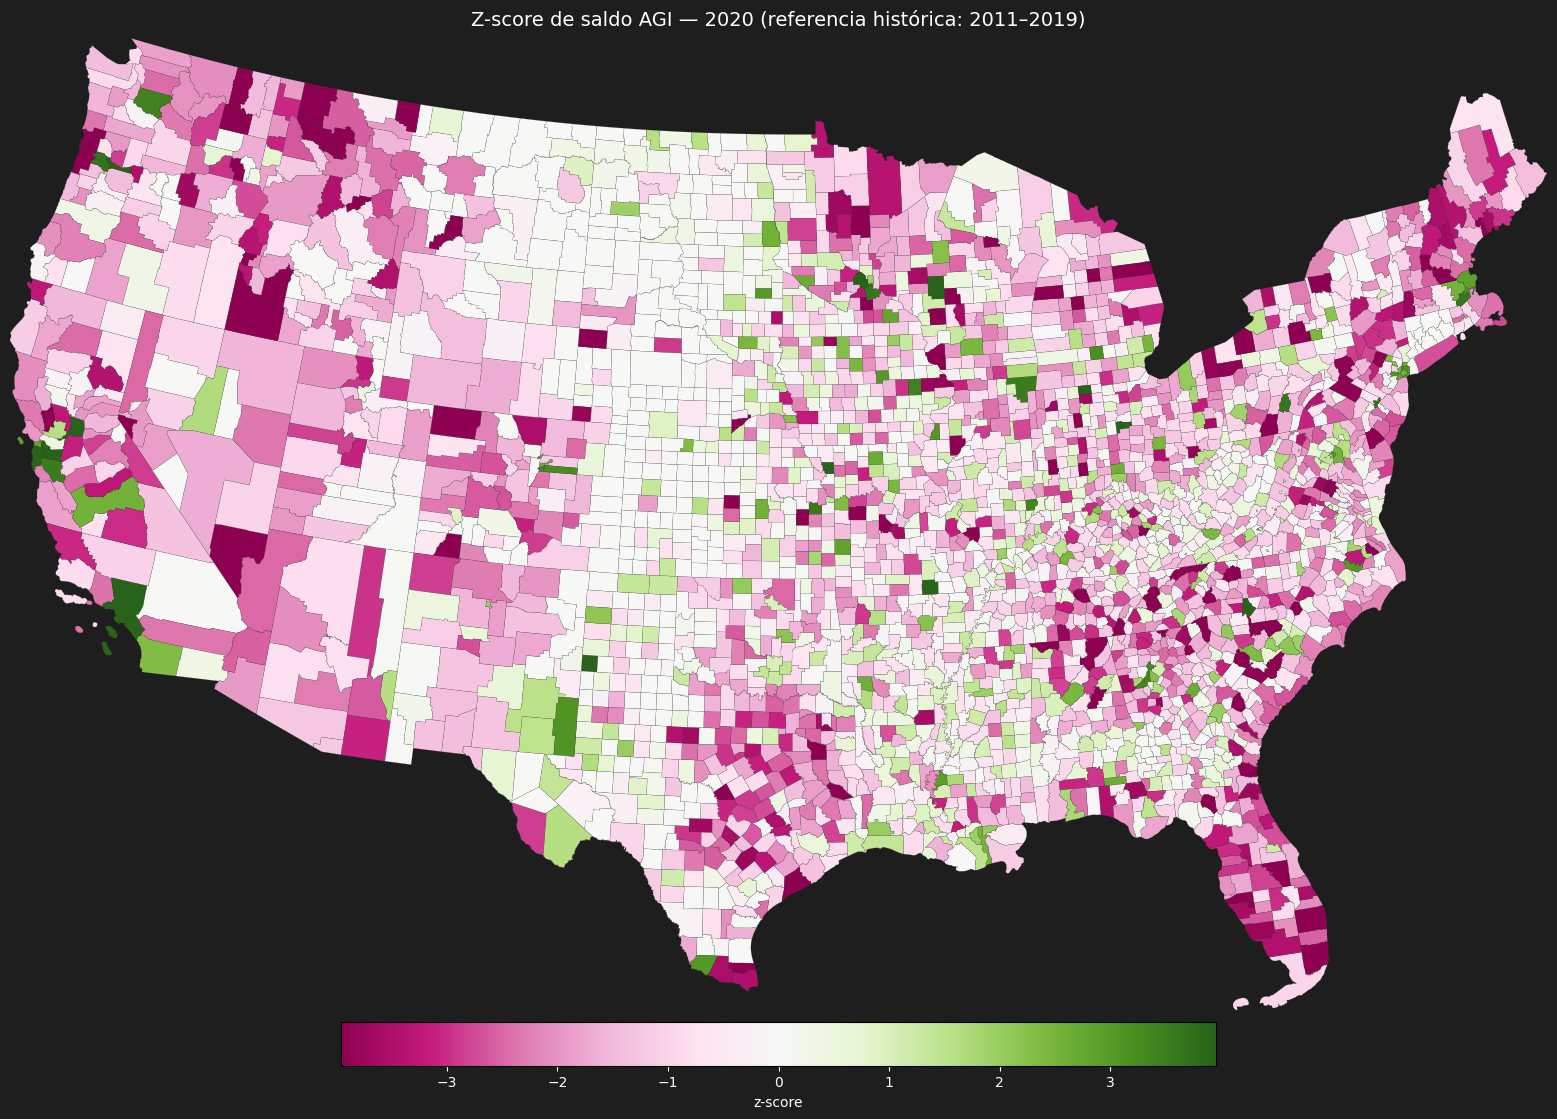

In [43]:
# Generado con IA (visualización)
z_2020_mapa = saldos_z[saldos_z['año'] == 2020][['FIP', 'z_AGI']].copy()
gdf_z2020 = gdf.merge(z_2020_mapa, on='FIP', how='left')
gdf_z2020['z_AGI'] = gdf_z2020['z_AGI'].fillna(0)

vmax_z = np.percentile(np.abs(gdf_z2020['z_AGI']), 97)
xmin, ymin, xmax, ymax = gdf_z2020.total_bounds

fig, ax = plt.subplots(figsize=(22, 12))
fig.patch.set_facecolor('#1e1e1e')
ax.set_facecolor('#1e1e1e')

gdf_z2020.plot(
    column='z_AGI', ax=ax, cmap='PiYG',
    vmin=-vmax_z, vmax=vmax_z, linewidth=0.1, edgecolor='#444',
    legend=True,
    legend_kwds={'label': 'z-score saldo AGI (2020)',
                 'orientation': 'horizontal', 'shrink': 0.4, 'pad': 0.01}
)
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_title('Z-score de saldo AGI — 2020 (referencia histórica: 2011–2019)',
             color='white', fontsize=14, pad=10)
ax.set_axis_off()
cbar = ax.get_figure().axes[-1]
cbar.tick_params(colors='white')
cbar.set_xlabel('z-score', color='white')
plt.tight_layout(pad=0.5)
plt.savefig(os.path.join(BASE, 'figuras/sec4_zscore_mapa2020.png'),
            dpi=150, bbox_inches='tight', facecolor='#1e1e1e')
plt.show()

El mapa de z-scores de 2020 no replica el coroplético de saldo acumulado. Un condado puede tener saldo positivo histórico y z negativo en 2020 si ese año fue peor que su media histórica.

Los condados con z más extremo (Wahkiakum WA, z = −11,5; Lincoln MT, z = −10,3) son pequeños con varianza histórica casi nula. Cualquier perturbación modesta les dispara el z a doble dígito. Miami-Dade (z = −9,0, saldo = −4.345 M$) es diferente: el z extremo y el volumen económico coinciden — fue el peor año del condado en toda la serie. En el extremo positivo, LA (z = +4,3), Chicago (z = +3,5) y Nueva York (z = +3,2) atrajeron más AGI del que su trayectoria anticipaba. El supuesto éxodo de las grandes ciudades no aparece en el saldo neto de AGI de 2020.

In [44]:
# Elaboración propia
nombres_top = gdf[['FIP', 'NAME', 'STATEFP']].copy()

for año_eval in [2017, 2020]:
    z_año = saldos_z[saldos_z['año'] == año_eval].copy()
    z_año['abs_z'] = z_año['z_AGI'].abs()
    top10 = z_año.nlargest(10, 'abs_z').merge(nombres_top, on='FIP', how='left')
    print(f'\nTop-10 más anómalos en {año_eval}:')
    print(top10[['FIP', 'NAME', 'STATEFP', 'z_AGI', 'saldo_AGI']].to_string(index=False))


Top-10 más anómalos en 2017:
  FIP         NAME STATEFP     z_AGI  saldo_AGI
48371        Pecos      48  2.660258    46865.0
31001        Adams      31  2.456608     6701.0
19043      Clayton      19 -2.437563    -4094.0
18021         Clay      18 -2.407411    -6048.0
29121        Macon      29  2.368955     3142.0
22123 West Carroll      22 -2.341053    -1764.0
47091      Johnson      47 -2.279746    -1724.0
31099      Kearney      31  2.268282      984.0
41049       Morrow      41 -2.248542     -612.0
38071       Ramsey      38 -2.239169     -165.0

Top-10 más anómalos en 2020:
  FIP         NAME STATEFP      z_AGI  saldo_AGI
53069    Wahkiakum      53 -11.509234    -3966.0
30053      Lincoln      30 -10.322036   -11368.0
33011 Hillsborough      33  -9.921330  -190523.0
12086   Miami-Dade      12  -9.015529 -4344702.0
39011     Auglaize      39   8.304994     4811.0
20139        Osage      20  -7.995120    -5358.0
48423        Smith      48  -7.856539  -109686.0
12121     Suwannee  

En 2017, ninguno de los cuatro condados de Harvey aparece en el top-10 nacional. Sus z-scores van de −0,7 a +1,4. El condado con mayor z ese año, Pecos TX (+2,66), es un condado rural sin relación con el huracán. Con resolución anual y 3.000 condados, los cuatro condados de Houston no producen anomalías que superen |z| > 2.

En 2020 hay dos tipos de casos. Wahkiakum, Lincoln y Hillsborough NH tienen z extremos pero saldos modestos en volumen absoluto — resultado de la varianza histórica mínima. Miami-Dade (z = −9,0, −4.345 M$) y Orange County CA (z = +7,1, +1.453 M$) son los únicos donde el z y la escala económica van juntos.

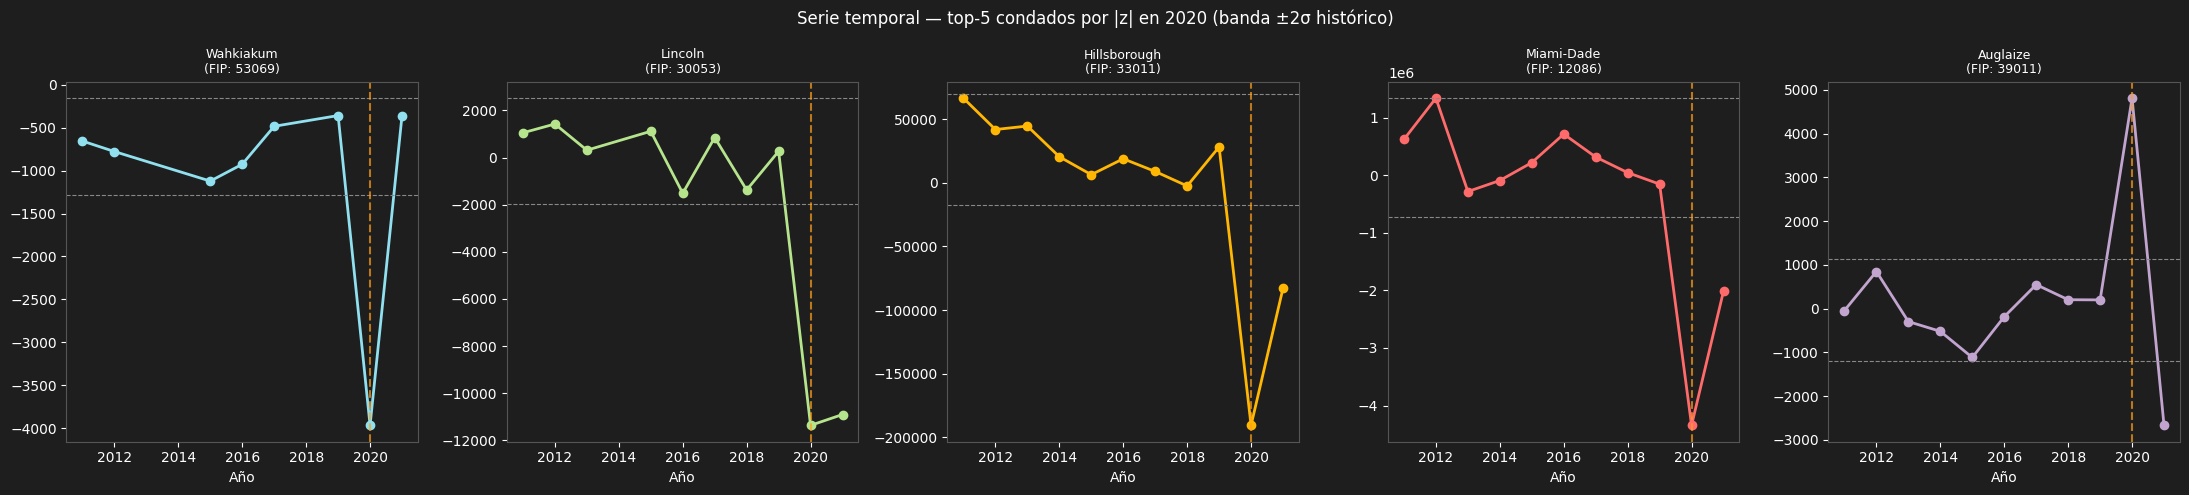

In [45]:
# Generado con IA (visualización)
z_2020_rank = saldos_z[saldos_z['año'] == 2020].copy()
z_2020_rank['abs_z'] = z_2020_rank['z_AGI'].abs()
top5_fips = z_2020_rank.nlargest(5, 'abs_z')['FIP'].tolist()

nombres_serie = gdf[['FIP', 'NAME']].copy()
top5_info = saldos_z[saldos_z['FIP'].isin(top5_fips)].merge(nombres_serie, on='FIP', how='left')

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
fig.patch.set_facecolor('#1e1e1e')
colores_serie = ['#90e0ef', '#b5e48c', '#ffb703', '#ff6b6b', '#c2a5cf']

for i, fip in enumerate(top5_fips):
    ax = axes[i]
    ax.set_facecolor('#1e1e1e')
    sub = top5_info[top5_info['FIP'] == fip].sort_values('año')
    nombre = sub['NAME'].iloc[0]
    media = sub['media_hist'].iloc[0]
    sigma = sub['std_hist'].iloc[0]
    ax.plot(sub['año'], sub['saldo_AGI'], marker='o', color=colores_serie[i], linewidth=2)
    ax.axhline(media + 2 * sigma, color='#888', linewidth=0.8, linestyle='--')
    ax.axhline(media - 2 * sigma, color='#888', linewidth=0.8, linestyle='--')
    ax.axvline(2020, color='#ff9f1c', linestyle='--', alpha=0.7)
    ax.set_title(f'{nombre}\n(FIP: {fip})', color='white', fontsize=9)
    ax.set_xlabel('Año', color='white')
    ax.tick_params(colors='white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#555')

fig.suptitle('Serie temporal — top-5 condados por |z| en 2020 (banda ±2σ histórico)',
             color='white', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(BASE, 'figuras/sec4_serie_top5.png'),
            dpi=150, bbox_inches='tight', facecolor='#1e1e1e')
plt.show()

Wahkiakum y Lincoln tienen la banda ±2σ casi invisible en la escala del gráfico: la varianza histórica es tan pequeña que cualquier variación de unos miles de dólares dispara el z. El punto de 2020 sale fuera, pero el eje Y llega solo a unos miles de miles de dólares. Ruptura estadística, no colapso económico.

Hillsborough NH sí tiene escala apreciable: los saldos históricos rondaban los 20.000–60.000 M$ y en 2020 cayó a −190.000 M$. Miami-Dade muestra la combinación más clara: banda amplia, punto de 2020 perforándola hacia abajo con margen. El saldo de −4.345 M$ es el más bajo del condado en toda la serie. Auglaize OH es el único positivo del grupo — registra en 2020 su mayor saldo histórico sin explicación obvia en los datos disponibles.

## 5. Anomalías espaciales

¿Los condados anómalos en 2020 están agrupados geográficamente o dispersos? Aplicamos LISA sobre el z-score de 2020 — no sobre el saldo crudo — y calculamos un variograma empírico con `skgstat` para estimar hasta qué distancia opera esa dependencia.

In [46]:
# Elaboración propia
z_2020_lisa = saldos_z[saldos_z['año'] == 2020][['FIP', 'z_AGI']].copy()
gdf_z = gdf.merge(z_2020_lisa, on='FIP', how='left')
gdf_z['z_AGI'] = gdf_z['z_AGI'].fillna(0)
gdf_z = gdf_z.reset_index(drop=True)

w_z = Queen.from_dataframe(gdf_z, silence_warnings=True)
w_z.transform = 'r'
y_z = gdf_z['z_AGI'].values

moran_z20 = Moran(y_z, w_z, permutations=9999)
print(f'Moran I sobre z-scores 2020 = {moran_z20.I:.4f} (p = {moran_z20.p_sim:.4f})')

lisa_z = Moran_Local(y_z, w_z, permutations=9999, seed=42)
gdf_z['lisa_z_q'] = lisa_z.q
gdf_z['lisa_z_p'] = lisa_z.p_sim
gdf_z['lisa_z_sig'] = lisa_z.p_sim < 0.05

def asignar_cluster_z(row):
    if not row['lisa_z_sig']:
        return 'NS'
    return {1: 'HH', 2: 'LH', 3: 'LL', 4: 'HL'}.get(row['lisa_z_q'], 'NS')

gdf_z['cluster_z'] = gdf_z.apply(asignar_cluster_z, axis=1)
print(gdf_z['cluster_z'].value_counts().to_string())

Moran I sobre z-scores 2020 = 0.1732 (p = 0.0001)
cluster_z
NS    2521
LL     253
HH     168
HL      94
LH      73


*Responde a la pregunta 5 (primera parte).*

Moran I sobre z-scores de 2020: I = 0,1732, p = 0,0001. Los condados que rompieron su histórico no se distribuyeron al azar. El LISA detecta 588 condados significativos, más del doble que en la Sección 3 (269 sobre el saldo acumulado). La pandemia generó más clústeres locales que el saldo acumulado de once años.

Los 2.521 condados en NS corresponden mayoritariamente a condados rurales pequeños con varianza histórica mínima: el z se dispara pero el vecindario inmediato no muestra el mismo comportamiento. Anomalía individual y agrupación espacial son fenómenos distintos; el COVID generó los dos, pero en proporciones desiguales.

In [ ]:
# Generado con IA (visualización)
xmin, ymin, xmax, ymax = gdf_z.total_bounds
fig, ax = plt.subplots(figsize=(22, 12))
fig.patch.set_facecolor('#1e1e1e')
ax.set_facecolor('#1e1e1e')

for tipo, color in COLORES_LISA.items():
    gdf_z[gdf_z['cluster_z'] == tipo].plot(
        ax=ax, color=color, linewidth=0.1, edgecolor='#333'
    )

etiquetas_z = {
    'HH': 'z alto — vecinos z alto', 'LL': 'z bajo — vecinos z bajo',
    'HL': 'z alto — vecinos z bajo', 'LH': 'z bajo — vecinos z alto',
    'NS': 'No significativo'
}
parches_z = [mpatches.Patch(color=COLORES_LISA[k], label=etiquetas_z[k])
             for k in ['HH', 'LL', 'HL', 'LH', 'NS']]
ax.legend(handles=parches_z, loc='lower left',
          facecolor='#1e1e1e', labelcolor='white', fontsize=11, framealpha=0.8)
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_title('LISA sobre z-score de saldo AGI — 2020 (p < 0.05)',
             color='white', fontsize=14, pad=10)
ax.set_axis_off()
plt.tight_layout(pad=0.5)
plt.savefig(os.path.join(BASE, 'figuras/sec5_lisa_zscore2020.png'),
            dpi=150, bbox_inches='tight', facecolor='#1e1e1e')
plt.show()

El mapa es más denso que el de la Sección 3c. Los LL (z bajo rodeado de z bajo) cubren el noroeste del Pacífico, las Rocosas y zonas del sureste — caída de AGI respecto al histórico compartida entre condados vecinos. Los HH se concentran en el Medio Oeste y el corredor del Noreste, donde las grandes metrópolis atrajeron en 2020 más AGI del que su serie histórica anticipaba.

Comparando con el LISA de saldo acumulado: el corredor californiano domina en la Sección 3c pero no aquí. California pierde AGI de forma crónica, y en 2020 eso no fue una anomalía respecto a su propio histórico. El mapa de z-scores captura el impacto pandémico específico de 2020, no el saldo estructural acumulado.

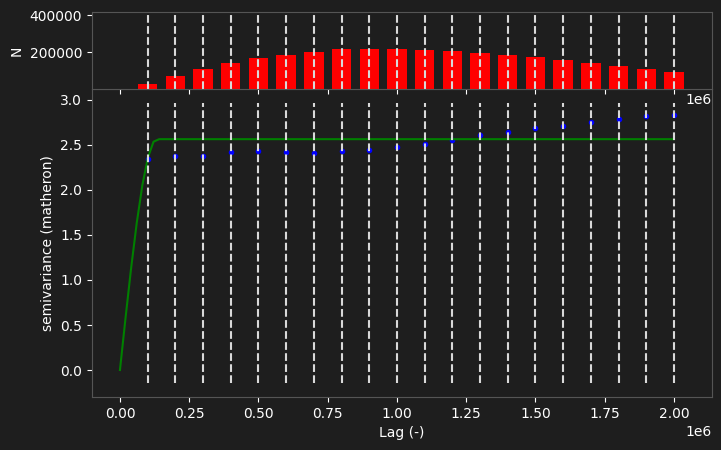

rango = 133 km, meseta = 2.5617, pepita = 0.0000


In [ ]:
# Generado con IA (visualización)
z_2020_var = saldos_z[saldos_z['año'] == 2020][['FIP', 'z_AGI']].copy()
gdf_var = gdf.merge(z_2020_var, on='FIP', how='inner').reset_index(drop=True)

centroides = gdf_var.geometry.centroid
coords = np.column_stack([centroides.x.values, centroides.y.values])
valores = gdf_var['z_AGI'].values

V = skg.Variogram(coords, valores, n_lags=20, maxlag=2_000_000, model='spherical')

fig = V.plot(show=False)
fig.patch.set_facecolor('#1e1e1e')
for ax_v in fig.axes:
    ax_v.set_facecolor('#1e1e1e')
    ax_v.tick_params(colors='white')
    ax_v.xaxis.label.set_color('white')
    ax_v.yaxis.label.set_color('white')
    ax_v.title.set_color('white')
    for spine in ax_v.spines.values():
        spine.set_edgecolor('#555')

plt.savefig(os.path.join(BASE, 'figuras/sec5_variograma_z2020.png'),
            dpi=150, bbox_inches='tight', facecolor='#1e1e1e')
plt.show()

rango_km = V.parameters[0] / 1000
print(f'rango = {rango_km:.0f} km, meseta = {V.parameters[1]:.4f}, pepita = {V.parameters[2]:.4f}')

*Responde a la pregunta 5 (segunda parte).*

El variograma ajusta un modelo esférico sobre los z-scores de 2020 usando las coordenadas de los centroides. La semivarianza empírica sube rápido en los primeros lags y la curva verde alcanza la meseta antes de los 250 km. A partir de ahí es plana hasta los 2.000 km del límite.

Parámetros del modelo: rango = 133 km, meseta = 2,56, pepita ≈ 0. El rango de 133 km corresponde aproximadamente al radio de un área metropolitana media. Dos condados separados por más de 133 km tienen z-scores estadísticamente independientes. La pepita baja confirma que la variabilidad en los z-scores está asociada a la posición geográfica, no a características aisladas de cada condado. El decaimiento rápido de la semivarianza también explica por qué el Moran en z-scores (0,17) queda algo por debajo del Moran del saldo acumulado (0,19).

## 6. Red de flujos y PageRank

El saldo neto dice quién gana y quién pierde. No dice quién procesa más flujo. Un condado puede tener saldo bajo — envía y recibe cantidades similares — y ser un hub: si algo le afecta, el impacto se extiende por muchas aristas. Construimos un grafo dirigido con los flujos acumulados 2011–2022, filtrando por encima del percentil 90 de AGI (umbral: 18.038 miles $). Resultado: 8.716 pares de 87.151, 1.377 nodos activos. PageRank ponderado por AGI.

In [ ]:
# Elaboración propia
flujos_acum = flujos.groupby(['FIP Origen', 'FIP Destino'])['AGI'].sum().reset_index()
umbral_p90 = np.percentile(flujos_acum['AGI'], 90)
flujos_top = flujos_acum[flujos_acum['AGI'] >= umbral_p90].copy()

print(f'umbral p90 AGI: {umbral_p90:,.0f} miles $  ->  {len(flujos_top):,} pares de {len(flujos_acum):,}')

G = nx.DiGraph()
for _, fila in flujos_top.iterrows():
    G.add_edge(fila['FIP Origen'], fila['FIP Destino'], weight=fila['AGI'])

print(f'{G.number_of_nodes():,} nodos, {G.number_of_edges():,} aristas')

pagerank = nx.pagerank(G, weight='weight')
df_pr = pd.DataFrame({'FIP': list(pagerank.keys()), 'pagerank': list(pagerank.values())})

umbral p90 AGI: 18,038 miles $  ->  8,716 pares de 87,151
1,377 nodos, 8,716 aristas


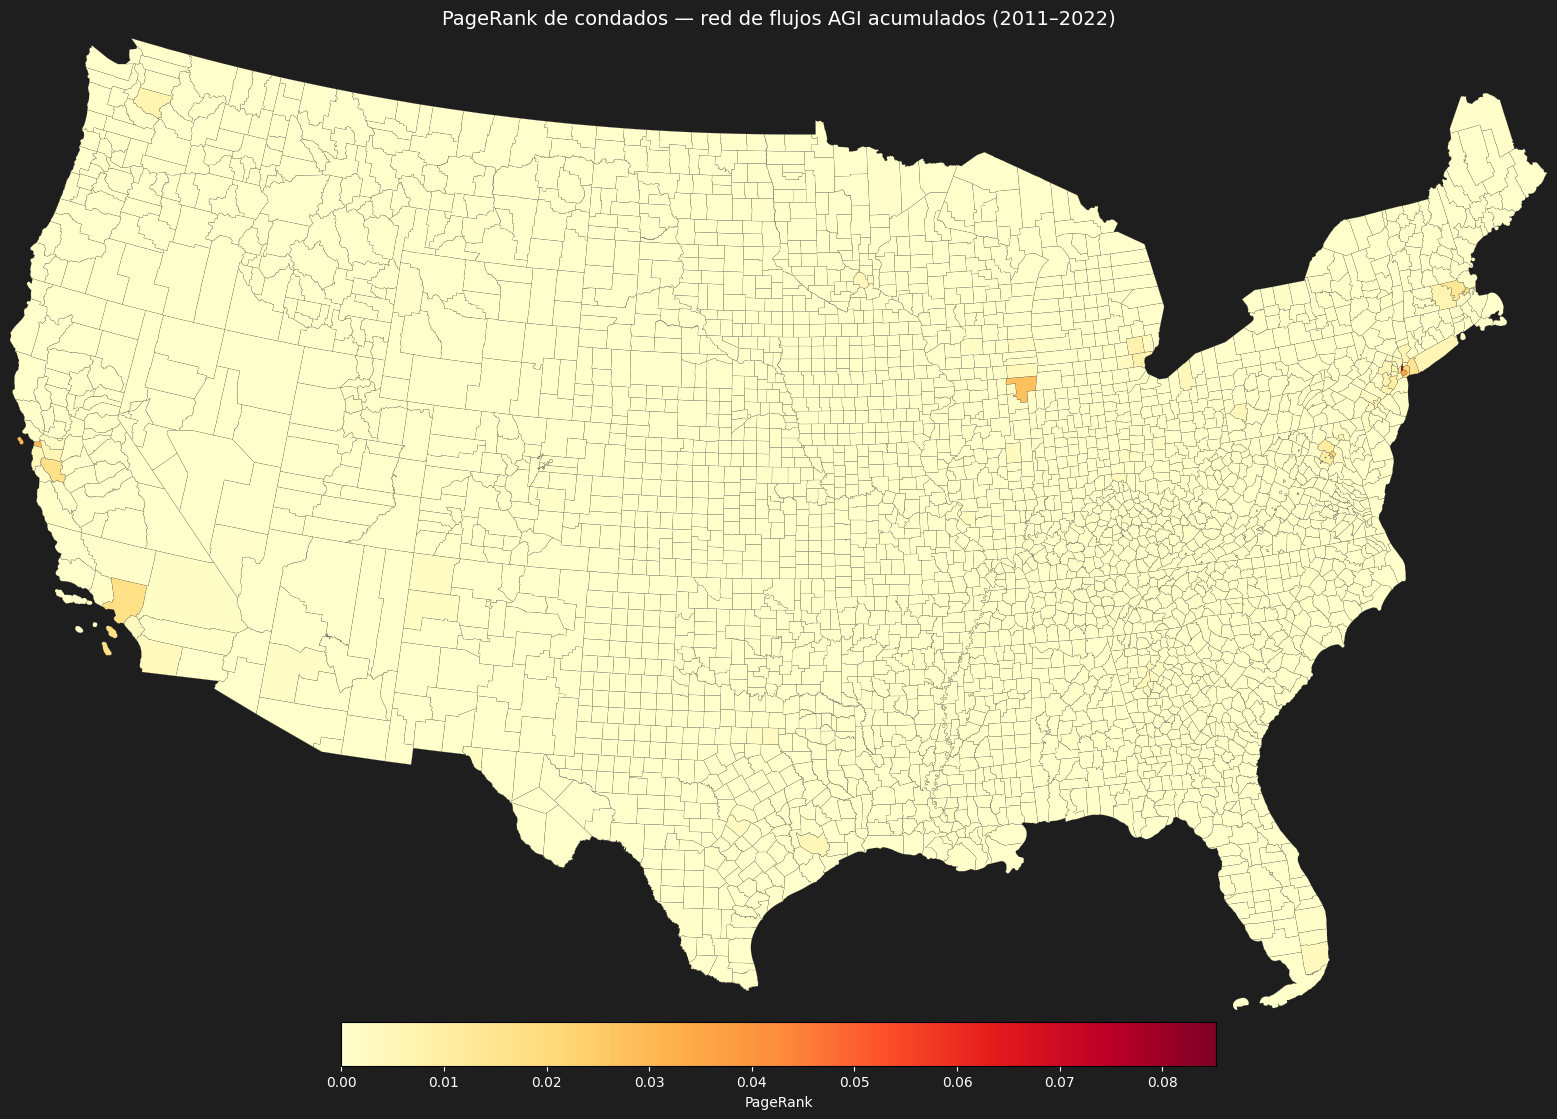

In [ ]:
# Generado con IA (visualización)
gdf_pr = gdf.merge(df_pr, on='FIP', how='left')
gdf_pr['pagerank'] = gdf_pr['pagerank'].fillna(0)

xmin, ymin, xmax, ymax = gdf_pr.total_bounds
fig, ax = plt.subplots(figsize=(22, 12))
fig.patch.set_facecolor('#1e1e1e')
ax.set_facecolor('#1e1e1e')

gdf_pr.plot(
    column='pagerank', ax=ax, cmap='YlOrRd',
    linewidth=0.1, edgecolor='#444',
    legend=True,
    legend_kwds={'label': 'PageRank (peso AGI)',
                 'orientation': 'horizontal', 'shrink': 0.4, 'pad': 0.01}
)
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_title('PageRank de condados — red de flujos AGI acumulados (2011–2022)',
             color='white', fontsize=14, pad=10)
ax.set_axis_off()
cbar = ax.get_figure().axes[-1]
cbar.tick_params(colors='white')
cbar.set_xlabel('PageRank', color='white')
plt.tight_layout(pad=0.5)
plt.savefig(os.path.join(BASE, 'figuras/sec6_pagerank_mapa.png'),
            dpi=150, bbox_inches='tight', facecolor='#1e1e1e')
plt.show()

*Responde a la pregunta 6.*

El 99% del territorio sale en crema (PR ≈ 0,00–0,01). Solo unas pocas manchas naranjas rompen la escala. Manhattan (PR = 0,085) dobla al segundo nodo de la lista. El top-10: Manhattan, Brooklyn, SF, Cook/Chicago, DC, Queens, Arlington VA, Suffolk MA, LA y Santa Clara.

El corredor Virginia–DC aparece con Arlington (0,019) y DC (0,022) — zonas con mucho flujo bidireccional de contratistas federales y organismos gubernamentales que mueven AGI en ambos sentidos sin acumular ventaja neta alta. La distribución de PageRank es muy asimétrica: los 10 primeros nodos de 1.377 acaparan una fracción desproporcionada de la centralidad.

In [ ]:
# Elaboración propia
nombres_pr = gdf[['FIP', 'NAME', 'STATEFP']].copy()

top10_pr = df_pr.nlargest(10, 'pagerank').merge(nombres_pr, on='FIP', how='left')
print('Top-10 PageRank:')
print(top10_pr[['FIP', 'NAME', 'STATEFP', 'pagerank']].to_string(index=False))

top10_saldo = saldos_tot.nlargest(10, 'saldo_AGI').merge(nombres_pr, on='FIP', how='left')
print('\nTop-10 saldo AGI acumulado (2011-2022):')
print(top10_saldo[['FIP', 'NAME', 'STATEFP', 'saldo_AGI']].to_string(index=False))

Top-10 PageRank:
  FIP                 NAME STATEFP  pagerank
36061             New York      36  0.085195
36047                Kings      36  0.035625
06075        San Francisco      06  0.030219
17031                 Cook      17  0.027847
11001 District of Columbia      11  0.021767
36081               Queens      36  0.020543
51013            Arlington      51  0.019049
25025              Suffolk      25  0.017560
06037          Los Angeles      06  0.017034
06085          Santa Clara      06  0.016434

Top-10 saldo AGI acumulado (2011-2022):
  FIP          NAME STATEFP  saldo_AGI
36061      New York      36 47575026.0
06037   Los Angeles      06 34691752.0
17031          Cook      17 34652027.0
06075 San Francisco      06 22900773.0
06085   Santa Clara      06 22713908.0
36081        Queens      36 14426643.0
36047         Kings      36 13752669.0
25017     Middlesex      25 11153457.0
48201        Harris      48 10192934.0
25025       Suffolk      25  9260574.0


Las dos listas se solapan en 8 de los 10 primeros puestos. Los grandes metros son simultáneamente los mayores receptores netos y los nodos más centrales. Las diferencias están en los dos que no coinciden.

En PageRank pero no en saldo: DC y Arlington. Procesan mucho AGI en ambas direcciones pero sin acumular ventaja neta destacada. En saldo pero no en PageRank: Harris TX (Houston, +10.193 M$) y Middlesex MA (+11.153 M$). Su posición de recepción neta es regional, no nacional. Comparar las dos métricas separa los hubs de cobertura nacional de los receptores de alcance más limitado.

## 7. Validación externa

Dos vías de validación. Un KS-test compara la distribución completa de saldos AGI en 2020 frente a 2013–2019. Un test de proporciones compara el porcentaje de condados con |z| > 2 entre los condados afectados por cada evento y el resto del país.

In [ ]:
# Elaboración propia
normal_saldos = saldos_z[saldos_z['año'].isin(range(2013, 2020))]['saldo_AGI'].values
covid_saldos  = saldos_z[saldos_z['año'] == 2020]['saldo_AGI'].values

ks_stat, ks_p = ks_2samp(normal_saldos, covid_saldos)
print(f'KS-test 2013-2019 vs 2020:  D = {ks_stat:.4f}, p = {ks_p:.2e}')

KS-test 2013-2019 vs 2020:  D = 0.1605, p = 1.59e-55


*Responde a la pregunta 7.*

D = 0,1605, p = 1,59 × 10⁻⁵⁵. Con más de 20.000 observaciones en la referencia y 3.000 en 2020, un D del 16% deja poco margen para interpretaciones alternativas. La distribución de saldos de 2020 no puede obtenerse muestreando años anteriores. Los percentiles cambian de posición y los extremos se ensanchan. 2020 no es un año extremo dentro del mismo régimen: la distribución es distinta.

In [ ]:
# Elaboración propia
from statsmodels.stats.proportion import proportions_ztest

EVENTOS = {
    'Harvey (2017)':       {'año': 2017, 'fips': ['48201', '48167', '48157', '48039']},
    'COVID urbano (2020)': {'año': 2020, 'fips': ['36061', '36047', '06075', '17031', '06037']},
}

nombres_ev = gdf[['FIP', 'NAME', 'STATEFP']].copy()

for nombre, ev in EVENTOS.items():
    año_ev = ev['año']
    fips_e = ev['fips']
    z_año  = saldos_z[saldos_z['año'] == año_ev].copy()
    z_año['anomalo'] = (z_año['z_AGI'].abs() > 2).astype(int)

    afect = z_año[z_año['FIP'].isin(fips_e)].merge(nombres_ev, on='FIP', how='left')
    resto = z_año[~z_año['FIP'].isin(fips_e)]

    n_af = len(afect);  x_af = afect['anomalo'].sum()
    n_re = len(resto);  x_re = resto['anomalo'].sum()

    stat_p, pval_p = proportions_ztest([x_af, x_re], [n_af, n_re])

    print(f'\n{nombre}')
    print(afect[['FIP', 'NAME', 'STATEFP', 'z_AGI']].to_string(index=False))
    print(f'anómalos: {x_af}/{n_af} ({x_af/n_af*100:.1f}%) vs resto {x_re}/{n_re} ({x_re/n_re*100:.1f}%)  |  z-test p={pval_p:.4f}')


Harvey (2017)
  FIP      NAME STATEFP     z_AGI
48039  Brazoria      48 -0.724729
48157 Fort Bend      48  1.361820
48167 Galveston      48  0.781760
48201    Harris      48  0.586228
anómalos: 0/4 (0.0%) vs resto 36/2786 (1.3%)  |  z-test p=0.8190

COVID urbano (2020)
  FIP          NAME STATEFP    z_AGI
06037   Los Angeles      06 4.250493
06075 San Francisco      06 2.833343
17031          Cook      17 3.533938
36047         Kings      36 2.505937
36061      New York      36 3.164988
anómalos: 5/5 (100.0%) vs resto 707/2796 (25.3%)  |  z-test p=0.0001


*Responde a la pregunta 8.*

**Harvey (2017):** los cuatro condados de referencia (Harris, Galveston, Brazoria y Fort Bend) tienen z entre −0,7 y +1,4. Ninguno supera |z| > 2. Proporción de anómalos: 0 de 4 (0%) frente a 1,3% en el resto del país. Test de proporciones: p = 0,82, no significativo. Con resolución anual, los desplazamientos temporales del huracán no generan anomalías estadísticas en los saldos de renta.

**COVID urbano (2020):** los cinco metros de referencia (Manhattan, Brooklyn, SF, Cook y LA) tienen todos |z| > 2 (100% frente a 25,3% en el resto). p < 0,001. Los z son positivos en los cinco casos, entre +2,5 y +4,3: esas ciudades no perdieron AGI en 2020, lo ganaron por encima de su media histórica. El colapso de las grandes metrópolis no aparece en los saldos netos de renta de ese año.

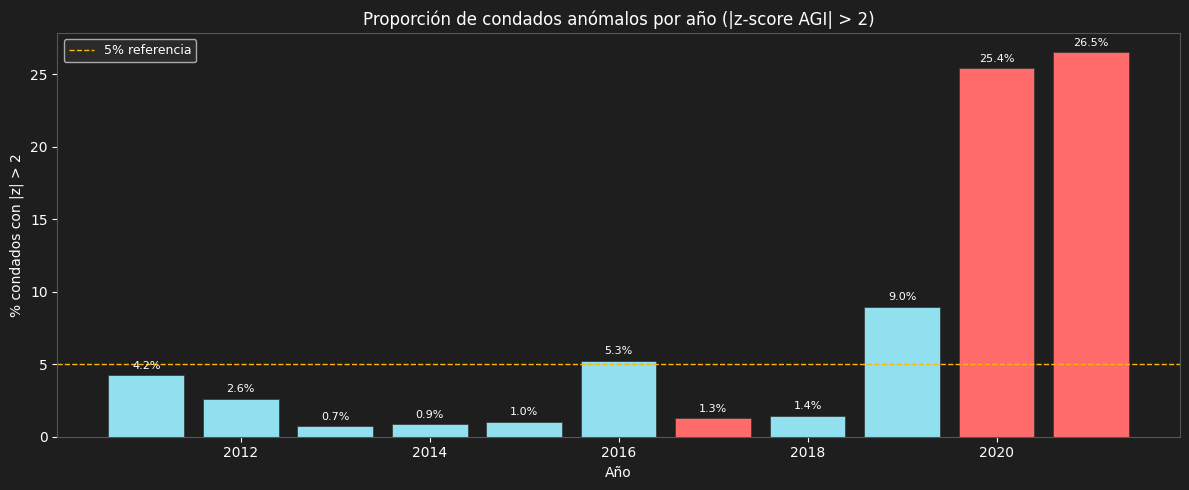

In [ ]:
# Generado con IA (visualización)
años_bar = sorted(saldos_z['año'].unique().astype(int))
pct_anom = []
for a in años_bar:
    sub = saldos_z[saldos_z['año'] == a]
    pct_anom.append((sub['z_AGI'].abs() > 2).mean() * 100)

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#1e1e1e')
ax.set_facecolor('#1e1e1e')

colores_bar = ['#ff6b6b' if a in [2017, 2020, 2021] else '#90e0ef' for a in años_bar]
ax.bar(años_bar, pct_anom, color=colores_bar, edgecolor='#333', linewidth=0.5)
ax.axhline(5, color='#ffb703', linewidth=1, linestyle='--', label='5% referencia')
ax.set_xlabel('Año', color='white')
ax.set_ylabel('% condados con |z| > 2', color='white')
ax.set_title('Proporción de condados anómalos por año (|z-score AGI| > 2)',
             color='white', fontsize=12)
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('#555')
ax.legend(facecolor='#2e2e2e', labelcolor='white', fontsize=9)
for a, p in zip(años_bar, pct_anom):
    ax.text(a, p + 0.3, f'{p:.1f}%', ha='center', va='bottom', color='white', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(BASE, 'figuras/sec7_pct_anomalos_año.png'),
            dpi=150, bbox_inches='tight', facecolor='#1e1e1e')
plt.show()

De 2011 a 2019, el porcentaje de condados anómalos oscila entre 0,7% y 9,0% sin tendencia clara. Solo 2016 (5,3%) y 2019 (9,0%) superan el 5%. Harvey 2017 produce 1,3%, dentro del nivel de fondo. El salto de 2020 (25,4%) no es la continuación acelerada del periodo anterior — cuatro veces más condados fuera de su rango histórico de forma simultánea es el valor más alto de la serie. 2021 (26,5%) confirma que no hubo reversión en el año siguiente.